In [74]:
import pandas as pd
df = pd.read_csv("online_retail.csv")

print(df.head())
print("..................................................................")
print(df.info())
print("..................................................................")
print(df.isnull().sum())
#print(df.shape[0])

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
..................................................................
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
--- 

In [75]:
# Handling missing values
df["Description"] = df["Description"].fillna("Unknown")
df["Customer ID"] = df["Customer ID"].fillna("Unknown")
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [76]:
# Convert Date
df.dtypes
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [77]:
# Revenue and sales performance
df["Revenue"] = df["Quantity"] * df["Price"]
df["Revenue"].sum()

np.float64(9539484.634)

In [78]:
# Top selling products
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

In [79]:
# Most returned items
df[df["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
...,...,...,...,...,...,...,...,...,...
525231,538159,21324,Unknown,-18,2010-12-09 17:17:00,0.00,Unknown,United Kingdom,-0.00
525232,538158,20892,Unknown,-32,2010-12-09 17:17:00,0.00,Unknown,United Kingdom,-0.00
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Unknown,United Kingdom,-0.00
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Unknown,United Kingdom,-0.00


In [80]:
# Top Customer
df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head(10)

Customer ID
Unknown    1191276.06
18102.0     341776.73
14646.0     243853.05
14156.0     183180.55
14911.0     137675.91
13694.0     128172.42
17511.0      83760.60
15061.0      82162.74
16684.0      75610.17
13089.0      55828.31
Name: Revenue, dtype: float64

In [81]:
# Revenue By country
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

In [82]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID            object
Country                   str
Revenue               float64
dtype: object

In [83]:
# Getting time based patterns
df["Hour"] = df["InvoiceDate"].dt.hour
df.groupby("Hour")["Revenue"].sum()

Hour
7       42931.900
8      242582.360
9      783137.620
10    1127537.702
11    1204162.923
12    1365831.561
13    1213628.634
14    1155534.430
15     979084.932
16     805010.331
17     400726.571
18     124735.330
19      74480.720
20      20104.570
21         -4.950
Name: Revenue, dtype: float64

In [84]:
# Pareto analysis (80/20 rule)
# Aggregate revenue by country
country_revenue = df.groupby("Country")["Revenue"].sum()
country_revenue = country_revenue.sort_values(ascending=False)
# Calculate cumulative %
cumulative = country_revenue.cumsum() / country_revenue.sum()

# Combine into a table
pareto_df = pd.DataFrame({
    "Revenue": country_revenue,
    "Cumulative %": cumulative
})
print(pareto_df)


                          Revenue  Cumulative %
Country                                        
United Kingdom        8194777.533      0.859038
EIRE                   352242.730      0.895962
Netherlands            263863.410      0.923623
Germany                196290.351      0.944199
France                 130769.900      0.957908
Sweden                  51213.510      0.963276
Denmark                 46972.950      0.968200
Switzerland             43343.410      0.972744
Spain                   37084.900      0.976631
Australia               30051.800      0.979781
Portugal                23769.780      0.982273
Belgium                 22663.530      0.984649
Channel Islands         21367.320      0.986889
Greece                  14284.970      0.988386
Italy                   13788.840      0.989832
Austria                 13023.280      0.991197
Cyprus                  11216.450      0.992373
Japan                    8435.960      0.993257
United Arab Emirates     8046.370      0

In [85]:
# Filter top 80%
top_80 = pareto_df[pareto_df["Cumulative %"] <= 0.9]
print(top_80)

                    Revenue  Cumulative %
Country                                  
United Kingdom  8194777.533      0.859038
EIRE             352242.730      0.895962


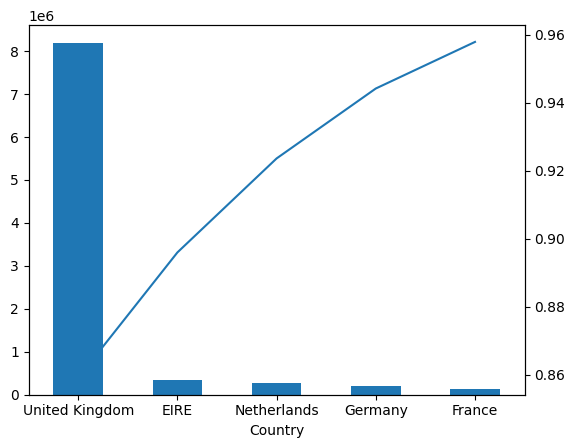

In [86]:
import matplotlib.pyplot as plt
top5 = pareto_df.head(5)
top5["Revenue"].plot(kind="bar")
top5["Cumulative %"].plot(secondary_y=True)

plt.show() 

In [91]:
# time-series analysis
import calendar
df["Month"] = df["InvoiceDate"].dt.month
monthly_revenue = df.groupby("Month")["Revenue"].sum().sort_values(ascending=False)
monthly_revenue.index = monthly_revenue.index.map(lambda x: calendar.month_name[x])
print(monthly_revenue)

Month
November     1422654.642
December     1177335.560
October      1045168.350
September     853650.431
March         765848.761
June          679786.610
August        656776.340
January       624032.892
May           615322.830
April         590580.432
July          575236.360
February      533091.426
Name: Revenue, dtype: float64


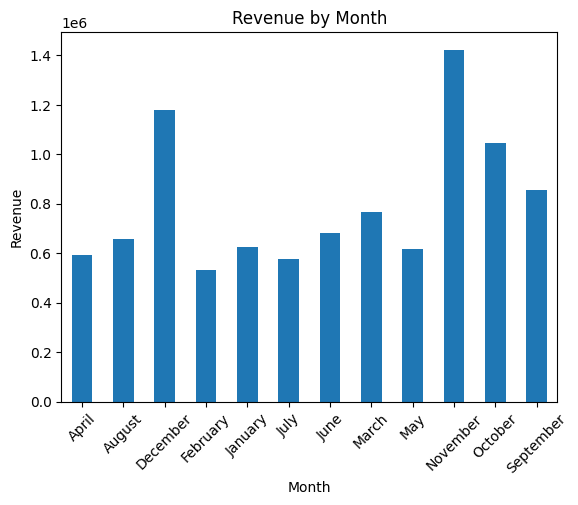

In [93]:
monthly_revenue.sort_index().plot(kind="bar")
plt.title("Revenue by Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [97]:
# Per year
df["Year"] = df["InvoiceDate"].dt.year
monthly_yearly = df.groupby(["Year", "Month"])["Revenue"].sum().unstack()
print(monthly_yearly)

Month          1           2           3           4          5          6   \
Year                                                                          
2009          NaN         NaN         NaN         NaN        NaN        NaN   
2010   624032.892  533091.426  765848.761  590580.432  615322.83  679786.61   

Month         7          8           9           10           11         12  
Year                                                                         
2009         NaN        NaN         NaN         NaN          NaN  799847.11  
2010   575236.36  656776.34  853650.431  1045168.35  1422654.642  377488.45  
